# Baby Naming Trends In The United States #

$Author$: Michael Simons

$Class$: MTH 448 - Data Oriented Computing

$Date$: 03/18/23

## Introduction ##

As our society evolves, so does the way we name our children. Names that were popular 100 years ago may not so popular today, and vice versa. But what drives these changes in popularity? Are the main influences popular culture, birth location, celebrity trends, or simply the passing of time? Additionally, how does gender play a role in the distribution of baby names? This report aims to explore these questions by analyzing the popularity trends of baby names in the United States over the last century.

The United States Social Security Administration has provided public access to records of information associated with newborn babies. In particular, the 'namesbystate' (available at https://www.ssa.gov/oact/babynames/limits.html) currently contains over 6.3 million records, and will be a valuable resource for exploring the evolution of baby naming. The dataset consists of a series of text files, all beginning with a capitalized two-letter state code. Each state's file contains information regarding the amount of babies of a certain sex born each year from 1910-2021. Every line in each state's file is a new entry with the following format:

2-digit state code, sex (M = male or F = female), 4-digit year of birth, the 2-15 character name, and the number of occurrences of the name. 
Fields are delimited with a comma.

## Gathering namesbystate Data ##

The downloaded namesbystate data is contained in a zip file. Using the zipfile library, the files will first be extracted into a folder called 'namesbystate'. Next, the glob library will conveniently provide a list of all the file names in the extracted directory that begin with a 2 letter state code and ending in ".TXT".

Pandas will be used to store and operate upon the data. Each of the collected file names will first be individually read into their own data frames. Once each file has its own data frame, the concat method can be used to combine all frames into one.

In [1]:
import pandas as pd
import glob
from zipfile import ZipFile 

with ZipFile("namesbystate.zip", 'r') as z: #Open zip file
    k=z.extractall(path='namesbystate') #Extract files to folder
file_names=glob.glob(r'namesbystate/[A-Z][A-Z].TXT') #Accumulate file names
frames=[pd.read_csv(file,names=["state","sex","year","name","count"]) for file in file_names] #List of data frames for each file
df=pd.concat(frames) #Combine all data frames into one

To ensure that the data has been properly extracted and formatted we will verify that there are over 6.3 million records, and we will display the first 5.

In [2]:
print(f"The dataframe contains {len(df)} records.")
df[:5]

The dataframe contains 6311504 records.


,state,sex,year,name,count
0,AK,F,1910,Mary,14
1,AK,F,1910,Annie,12
2,AK,F,1910,Anna,10
3,AK,F,1910,Margaret,8
4,AK,F,1910,Helen,7


## Trend Visualization ##

An effective way to display the popularity trends of certain names is by creating a heatmap. Heatmaps are a useful tool in visualizing data, where values are mapped to colors to provide a clear understanding of the distribution and patterns. In our case, the heatmap will show the popularity of for a given name in a given year.

Prior to creating the heatmap, we will compute the most popular male and female names within roughly the last 50 years. (1971-2021). First, the data should be filtered to only include records after 1970. Once the data has been filtered by year, it can again be filtered by sex so we can aggregate the top 15 names for both males and females. Grouping the filtered data by name will allow for a summation of every name's count each year since 1970.

In [3]:
# Filter data to past 50 years
last_50_yrs = df[df['year'] >= 1971]

# Get top 15 male and female names
top_15_male_names = last_50_yrs[last_50_yrs['sex'] == 'M'].groupby('name')['count'].sum().nlargest(15).index
top_15_female_names = last_50_yrs[last_50_yrs['sex'] == 'F'].groupby('name')['count'].sum().nlargest(15).index

# Filter data to top 15 male/female names only
top_15_last_50_yrs = last_50_yrs[last_50_yrs['name'].isin(top_15_male_names) | last_50_yrs['name'].isin(top_15_female_names)]

To visualize the trends of the top 15 male and female names, we will create a pivot table of the filtered data with names as the index, years as columns, and counts as values. We will then use this table to create a heatmap using the seaborn libray.

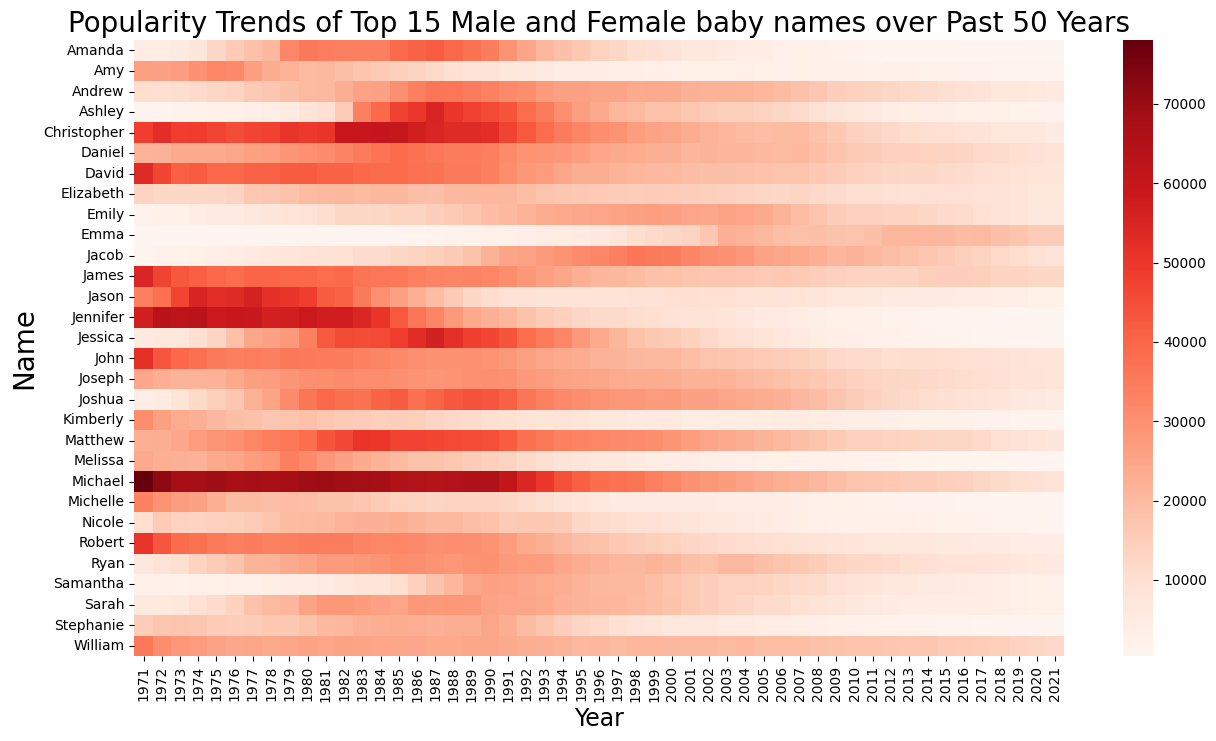

In [4]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
# Create pivot table
table = top_15_last_50_yrs.pivot_table(values='count', index='name', columns='year', aggfunc="sum")
# Create heatmap
_,ax = plt.subplots(figsize=(15, 8)) #Allocate larger plot space
sns.heatmap(table, cmap='Reds', ax=ax) #Fit data into heatmap
# Set title and labels
ax.set_title('Popularity Trends of Top 15 Male and Female baby names over Past 50 Years', fontsize=20) 
ax.set_xlabel('Year', fontsize=17)
ax.set_ylabel('Name', fontsize=20)
plt.show()

The produced heatmap shows the popularity trends of the top 15 male and female baby names in the United States over the past 50 years (1971-2021). The x-axis represents the years from 1971 to 2021, while the y-axis represents the names. The heatmap is color-coded, with darker shades of red indicating higher popularity and lighter shades indicating lower popularity.

Looking at the heatmap, we can see that some names have remained consistently popular over the past 50 years, such as William and Elizabeth. Other names however, have experienced fluctuations in popularity, such as Ashley, which was very popular in the 1990s but has since declined in popularity.

Visually speaking, Michael seems to be the name that has been the most popular over the past 50 years. There are several potential reasons why Michael was so popular during the 70s,80s, and 90s. Not only does it have biblical roots, but many famous celebrities of this era were named Michael, such as Michael Jackson. Another example is the character "Michael Corleone" from the Godfather, arguably the most famous movies of all time. Michael Jordan is the most famous basketball player of all time. Mike Tyson is arguably the most famous boxer of all time. These countless examples seem enough to suggest that the name has maintained popularity due to so many cultural icons having the name.

##  Gender Distribution of Baby Names ##

Another interesting aspect of the dataset is the distribution of names based on gender. Some names are given exclusively to male babies, some only to female babies, and some are given to both males and females. We can explore this distribution by first identifying the names that are given to both males and females. We can group the dataset by name and sex and count the number of unique states that have used each name for each sex. If a name appears with both 'M' and 'F' sex codes, we can consider it to be a unisex name. This section will aim to compute the amount percentage of names that are unisex.

In [5]:
# Group by name and sex, and count the unique states that have used each name for each sex
name_sex_counts = df.groupby(["name", "sex"])["state"].nunique().reset_index()

# Get the names that appear with both 'M' and 'F' sex codes
male_counts = name_sex_counts[name_sex_counts["sex"] == "M"]
female_counts = name_sex_counts[name_sex_counts["sex"] == "F"]
filtered_nsm = male_counts.merge(female_counts, on="name", how="inner")["name"]

# Count the number of names that are given only to male babies
male_exclusive_counts = (male_counts[~male_counts["name"].isin(filtered_nsm)]["name"]).nunique()

# Count the number of names that are given only to female babies
female_exclusive_counts = (female_counts[~female_counts["name"].isin(filtered_nsm)]["name"]).nunique()

# Count the number of names that are given to both males and females
unisex_counts = (name_sex_counts[name_sex_counts["name"].isin(filtered_nsm)]["name"]).nunique()

# Calculate the fraction of names in each category
total_names = name_sex_counts["name"].nunique()
male_exclusive_pct = male_exclusive_counts / total_names
female_exclusive_pct = female_exclusive_counts / total_names
unisex_pct = unisex_counts / total_names

# Print the results
print(f"Fraction of names given exclusively to male babies: {male_exclusive_pct}")
print(f"Fraction of names given exclusively to female babies: {female_exclusive_pct}")
print(f"Fraction of names given to both males and females: {unisex_pct}")

Fraction of names given exclusively to male babies: 0.3403388575131932
Fraction of names given exclusively to female babies: 0.5623861988087523
Fraction of names given to both males and females: 0.0972749436780545


These results suggest that there is a larger variety of names for female babies compared to male babies. It is interesting to note that almost 10% of the names are unisex, indicating a trend towards gender-neutral names.

## Trend of Unique Names over time ##

Let's examine whether parents are becoming more creative with naming over time by looking at the number of unique names each year.

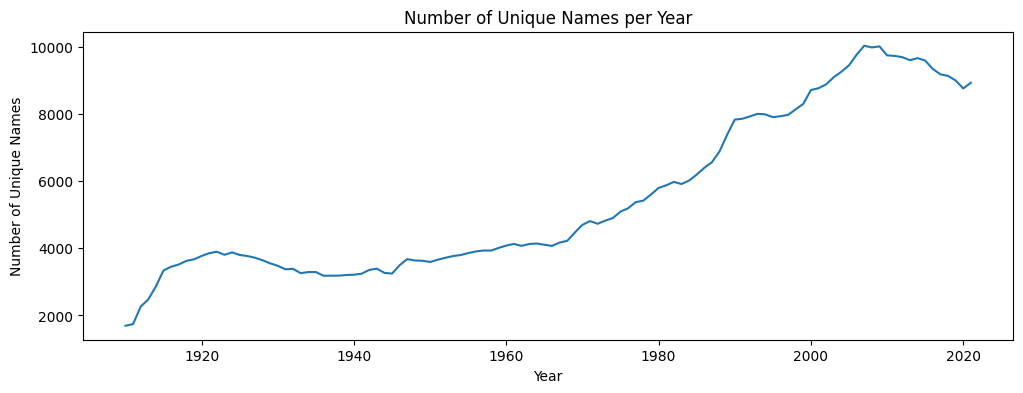

In [6]:
# Count unique names per year
unique_names_per_year = df.groupby('year')['name'].nunique()

# Plot the trend
plt.figure(figsize=(12, 4))
plt.plot(unique_names_per_year.index, unique_names_per_year.values)
plt.title('Number of Unique Names per Year')
plt.xlabel('Year')
plt.ylabel('Number of Unique Names')
plt.show()

The trend in the number of unique baby names over time shows an increase in the variety of names chosen by parents, particularly in recent decades. This suggests a shift in societal values toward individuality and uniqueness in naming conventions. From the early 20th century to around the 1980s, the number of unique names remained relatively stable, indicating a preference for traditional or common names. However, after the 1980s, there is a clear upward trend, signaling that parents are increasingly opting for more diverse and creative names. This could be influenced by various factors, including greater cultural diversity, increased media influence, and a growing desire for personalized identity expression.

## Exploring Geographic Variations in Baby Naming ##


Through the use of KMeans clustering, five distinct groups of states will be identified based on their baby naming preferences. By visualizing these clusters on a geographic map we will observe the similarities of states across various parts of the country.

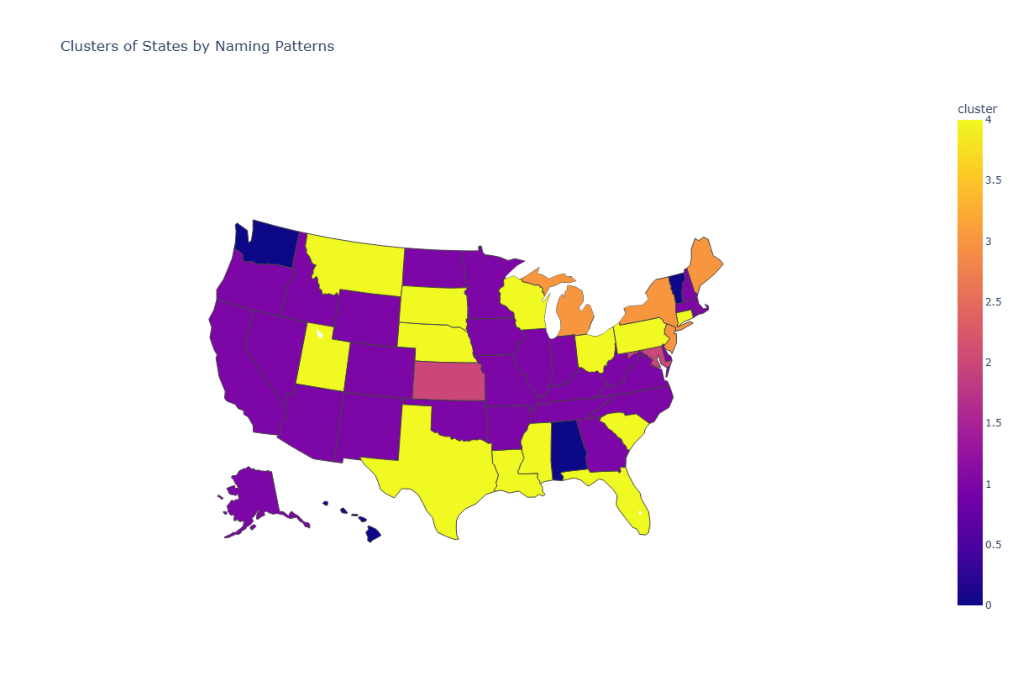

In [18]:
from sklearn.cluster import KMeans
import geopandas as gpd

#Load the geographic shapefile
us_states = gpd.read_file('tl_2024_us_state.shp')

#Group and pivot the baby naming data
state_name_grouped = df.groupby(['state', 'name', 'sex']).agg(total_count=('count', 'sum')).reset_index()
name_by_state = state_name_grouped.pivot_table(index='state', columns='name', values='total_count', aggfunc='sum', fill_value=0)

#Filter us_states to include only rows that match the 'state' codes in name_by_state
us_states = us_states[us_states['STUSPS'].isin(name_by_state.index)]

#Fit KMeans Clustering model to group similar states
kmeans = KMeans(n_clusters=5, random_state=42)
state_clusters = kmeans.fit_predict(name_by_state)

#Add the cluster information to the geographic dataset
us_states['cluster'] = state_clusters

#Create interactive map for clusters using Plotly
import plotly.express as px
fig = px.choropleth(us_states, 
                    locations='STUSPS', 
                    locationmode='USA-states', 
                    color='cluster', 
                    scope='usa', 
                    title='Clusters of States by Naming Patterns',
                    width=1200,
                    height=800)
fig.show()

This clustering points to how the demographic shifts may shape future naming conventions in the U.S.

## Conclusion ##

This report analyzed the popularity trends of baby names in the United States over the last century. The data was gathered from the United States Social Security Administration. The analysis explored the factors that influence the changes in the popularity of baby names, such as popular culture, birth location, and celebrity trends. Furthermore, the analysis investigated the role gender plays in the distribution of baby names and how the variety of unique names has increased over time, particularly after the 1980s, reflecting a societal shift toward individuality and creative naming. The report demonstrated the visualization of the popularity trends of the top 15 male and female names using heatmaps created with the Seaborn library. Future directions in studying this dataset could include exploring the relationship between baby names and geographic factors, such as location, and how these factors contribute to the popularity of certain names. Additionally, researchers could examine the influence of popular culture and media on baby names and how this impact has changed over time.

## References ##

[1] "Popular Baby Names." Social Security Administration.https://www.ssa.gov/oact/babynames/limits.html

[2] "pandas.pivot_table." pandas documentation.https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html

[3] "seaborn.heatmap." seaborn documentation.https://seaborn.pydata.org/generated/seaborn.heatmap.html

[4] "Famous People Named Michael." Ranker.https://www.ranker.com/list/famous-people-named-michael/celebrity-lists